## Mount to Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Packages

In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

## Load datasets

In [4]:
# Load datasets
prices = pd.read_csv('/content/drive/MyDrive/Data set/prices.csv')
prices_split_adjusted = pd.read_csv('/content/drive/MyDrive/Data set/prices-split-adjusted.csv')
securities = pd.read_csv('/content/drive/MyDrive/Data set/securities.csv')
fundamentals = pd.read_csv('/content/drive/MyDrive/Data set/fundamentals.csv')

In [5]:
# Merge prices and prices_split_adjusted on 'symbol' and 'date'
merged_prices = pd.merge(prices, prices_split_adjusted, on=['symbol', 'date'], suffixes=('', '_adjusted'))

# Merge with securities on 'symbol' and 'Ticker symbol'
merged_data = pd.merge(merged_prices, securities, left_on='symbol', right_on='Ticker symbol')

# Merge with fundamentals on 'symbol' and 'Ticker symbol'
merged_data = pd.merge(merged_prices, fundamentals, left_on='symbol', right_on='Ticker Symbol')



# EDA

### 1. Display first few rows of each dataset

In [6]:
prices.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05 00:00:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06 00:00:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07 00:00:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08 00:00:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11 00:00:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


In [7]:
prices_split_adjusted.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


In [8]:
securities.head()

,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
0,MMM,3M Company,reports,Industrials,Industrial Conglomerates,"St. Paul, Minnesota",NaN,66740
1,ABT,Abbott Laboratories,reports,Health Care,Health Care Equipment,"North Chicago, Illinois",1964-03-31,1800
2,ABBV,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",2012-12-31,1551152
3,ACN,Accenture plc,reports,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373
4,ATVI,Activision Blizzard,reports,Information Technology,Home Entertainment Software,"Santa Monica, California",2015-08-31,718877


In [9]:
fundamentals.head()

,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08
1,1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,...,1.432300e+10,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08
2,2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,...,1.175000e+10,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08
3,3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,...,9.985000e+09,1.360500e+10,5.635000e+09,4.278000e+10,4.841500e+10,4.099000e+10,0.0,2015.0,11.39,6.681299e+08
4,4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,...,3.184200e+09,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07


### 2. Summary of the datasets

In [10]:
print("Price Dataset")
print(prices.info())

Price Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB
None


In [11]:
print("Prices_split_adjusted Dataset")
print(prices_split_adjusted.info())

Prices_split_adjusted Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB
None


In [12]:
print("Securities Dataset")
print(securities.info())

Securities Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Ticker symbol            505 non-null    object
 1   Security                 505 non-null    object
 2   SEC filings              505 non-null    object
 3   GICS Sector              505 non-null    object
 4   GICS Sub Industry        505 non-null    object
 5   Address of Headquarters  505 non-null    object
 6   Date first added         307 non-null    object
 7   CIK                      505 non-null    int64 
dtypes: int64(1), object(7)
memory usage: 31.7+ KB
None


In [13]:
print("Fundamentals Dataset")
print(fundamentals.info())

Fundamentals Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 79 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Unnamed: 0                                           1781 non-null   int64  
 1   Ticker Symbol                                        1781 non-null   object 
 2   Period Ending                                        1781 non-null   object 
 3   Accounts Payable                                     1781 non-null   float64
 4   Accounts Receivable                                  1781 non-null   float64
 5   Add'l income/expense items                           1781 non-null   float64
 6   After Tax ROE                                        1781 non-null   float64
 7   Capital Expenditures                                 1781 non-null   float64
 8   Capital Surplus                                

### 3. Check for Missing Values

In [14]:
print("Price Dataset")
print(prices.isnull().sum())

Price Dataset
date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64


In [15]:
print("Prices_split_adjusted Dataset")
print(prices_split_adjusted.isnull().sum())

Prices_split_adjusted Dataset
date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64


In [16]:
print("Securities Dataset")
print(securities.isnull().sum())

Securities Dataset
Ticker symbol                0
Security                     0
SEC filings                  0
GICS Sector                  0
GICS Sub Industry            0
Address of Headquarters      0
Date first added           198
CIK                          0
dtype: int64


In [17]:
# Print the dataset name
print("Fundamentals Dataset")

# Print column-wise null value counts
for column in fundamentals.columns:
    print(f"{column}: {fundamentals[column].isnull().sum()} records")

Fundamentals Dataset
Unnamed: 0: 0 records
Ticker Symbol: 0 records
Period Ending: 0 records
Accounts Payable: 0 records
Accounts Receivable: 0 records
Add'l income/expense items: 0 records
After Tax ROE: 0 records
Capital Expenditures: 0 records
Capital Surplus: 0 records
Cash Ratio: 299 records
Cash and Cash Equivalents: 0 records
Changes in Inventories: 0 records
Common Stocks: 0 records
Cost of Revenue: 0 records
Current Ratio: 299 records
Deferred Asset Charges: 0 records
Deferred Liability Charges: 0 records
Depreciation: 0 records
Earnings Before Interest and Tax: 0 records
Earnings Before Tax: 0 records
Effect of Exchange Rate: 0 records
Equity Earnings/Loss Unconsolidated Subsidiary: 0 records
Fixed Assets: 0 records
Goodwill: 0 records
Gross Margin: 0 records
Gross Profit: 0 records
Income Tax: 0 records
Intangible Assets: 0 records
Interest Expense: 0 records
Inventory: 0 records
Investments: 0 records
Liabilities: 0 records
Long-Term Debt: 0 records
Long-Term Investments: 0

### 4. Descriptive Statistics

In [18]:
print("Prices Dataset")
prices.describe()

Prices Dataset


,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,70.836986,70.857109,70.118414,71.543476,5.415113e+06
std,83.695876,83.689686,82.877294,84.465504,1.249468e+07
min,0.850000,0.860000,0.830000,0.880000,0.000000e+00
25%,33.840000,33.849998,33.480000,34.189999,1.221500e+06
50%,52.770000,52.799999,52.230000,53.310001,2.476250e+06
75%,79.879997,79.889999,79.110001,80.610001,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


In [19]:
print("Prices_split_adjusted Dataset")
prices_split_adjusted.describe()

Prices_split_adjusted Dataset


,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,64.993618,65.011913,64.336541,65.639748,5.415113e+06
std,75.203893,75.201216,74.459518,75.906861,1.249468e+07
min,1.660000,1.590000,1.500000,1.810000,0.000000e+00
25%,31.270000,31.292776,30.940001,31.620001,1.221500e+06
50%,48.459999,48.480000,47.970001,48.959999,2.476250e+06
75%,75.120003,75.139999,74.400002,75.849998,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


In [20]:
print("Securities Dataset")
securities.describe()

Securities Dataset


,CIK
count,5.050000e+02
mean,7.074490e+05
std,5.144375e+05
min,1.800000e+03
25%,8.631200e+04
50%,8.310010e+05
75%,1.075531e+06
max,1.659166e+06


In [21]:
print("Fundamentals Dataset")
fundamentals.describe()

Fundamentals Dataset


,Unnamed: 0,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,Changes in Inventories,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
count,1781.000000,1.781000e+03,1.781000e+03,1.781000e+03,1781.000000,1.781000e+03,1.781000e+03,1482.000000,1.781000e+03,1.781000e+03,...,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1608.000000,1562.000000,1.562000e+03
mean,890.000000,4.673418e+09,-6.353484e+07,6.908940e+07,43.601348,-1.251925e+09,5.351784e+09,74.457490,8.521399e+09,-6.787749e+07,...,6.726349e+09,4.699919e+09,1.188846e+10,4.380420e+10,5.569266e+10,2.029154e+10,-3.951522e+09,2013.305348,3.353707,6.024244e+08
std,514.274732,1.406047e+10,7.562794e+08,6.848143e+08,233.924028,2.979963e+09,1.133977e+10,102.298374,5.432105e+10,3.903369e+08,...,1.344800e+10,9.538832e+09,2.584429e+10,1.817039e+11,2.033612e+11,4.095355e+10,1.407047e+10,19.953135,4.695896,1.142585e+09
min,0.000000,0.000000e+00,-6.452000e+09,-6.768000e+09,0.000000,-3.798500e+10,-7.215000e+08,0.000000,2.100000e+04,-5.562000e+09,...,0.000000e+00,0.000000e+00,-1.324400e+10,2.577000e+06,2.705000e+06,1.514000e+06,-2.297340e+11,1215.000000,-61.200000,-1.513945e+09
25%,445.000000,5.160000e+08,-1.040000e+08,-2.638000e+06,10.000000,-1.151200e+09,4.791000e+08,17.000000,3.088000e+08,-5.400000e+07,...,1.044178e+09,5.640760e+08,2.201492e+09,3.843300e+09,6.552689e+09,3.714000e+09,-3.040895e+09,2013.000000,1.590000,1.493318e+08
50%,890.000000,1.334000e+09,-1.830000e+07,2.000000e+06,16.000000,-3.580000e+08,1.997080e+09,41.000000,8.625900e+08,0.000000e+00,...,2.747200e+09,1.701500e+09,4.983000e+09,9.141000e+09,1.517000e+10,8.023200e+09,-3.068350e+08,2014.000000,2.810000,2.929409e+08
75%,1335.000000,3.246000e+09,7.816000e+06,3.359200e+07,26.000000,-1.291000e+08,5.735000e+09,90.000000,2.310000e+09,0.000000e+00,...,6.162000e+09,4.381000e+09,1.080900e+10,2.389700e+10,3.599710e+10,1.748600e+10,0.000000e+00,2015.000000,4.590000,5.492163e+08
max,1780.000000,2.069390e+11,2.266400e+10,1.416200e+10,5789.000000,5.000000e+06,1.082880e+11,1041.000000,7.281110e+11,3.755000e+09,...,1.396600e+11,9.028100e+10,2.562050e+11,2.340547e+12,2.572274e+12,4.856510e+11,0.000000e+00,2016.000000,50.090000,1.610769e+10


In [22]:
# Assuming 'merged_data' from the provided code is available.
unique_symbols = merged_data['symbol'].unique()


<ipython-input-23-dec123c3ebf0>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  microsoft_data['date'] = pd.to_datetime(microsoft_data['date'])


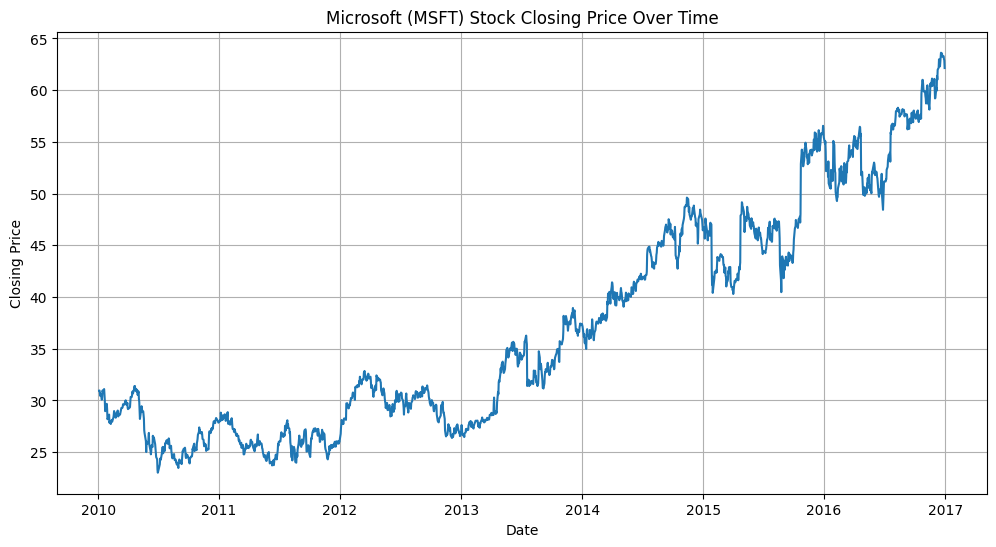

In [23]:

# Filter data for Microsoft (MSFT)
microsoft_data = merged_data[merged_data['symbol'] == 'MSFT']

# Convert 'date' column to datetime objects
microsoft_data['date'] = pd.to_datetime(microsoft_data['date'])

# Sort by date
microsoft_data = microsoft_data.sort_values('date')

# Plot the 'close' price over time
plt.figure(figsize=(12, 6))
plt.plot(microsoft_data['date'], microsoft_data['close'])
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Microsoft (MSFT) Stock Closing Price Over Time')
plt.grid(True)
plt.show()


###  Distribution of sectors

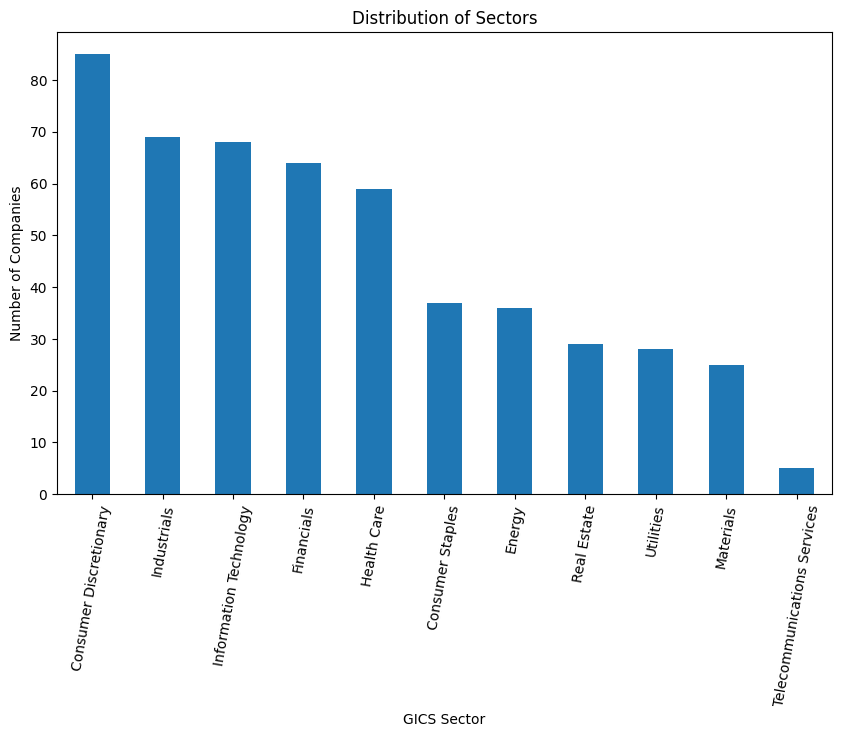

In [24]:
# Distribution of sectors
plt.figure(figsize=(10, 6))
securities['GICS Sector'].value_counts().plot(kind='bar')
plt.title('Distribution of Sectors')
plt.xlabel('GICS Sector')
plt.ylabel('Number of Companies')
plt.xticks(rotation=80)
plt.show()

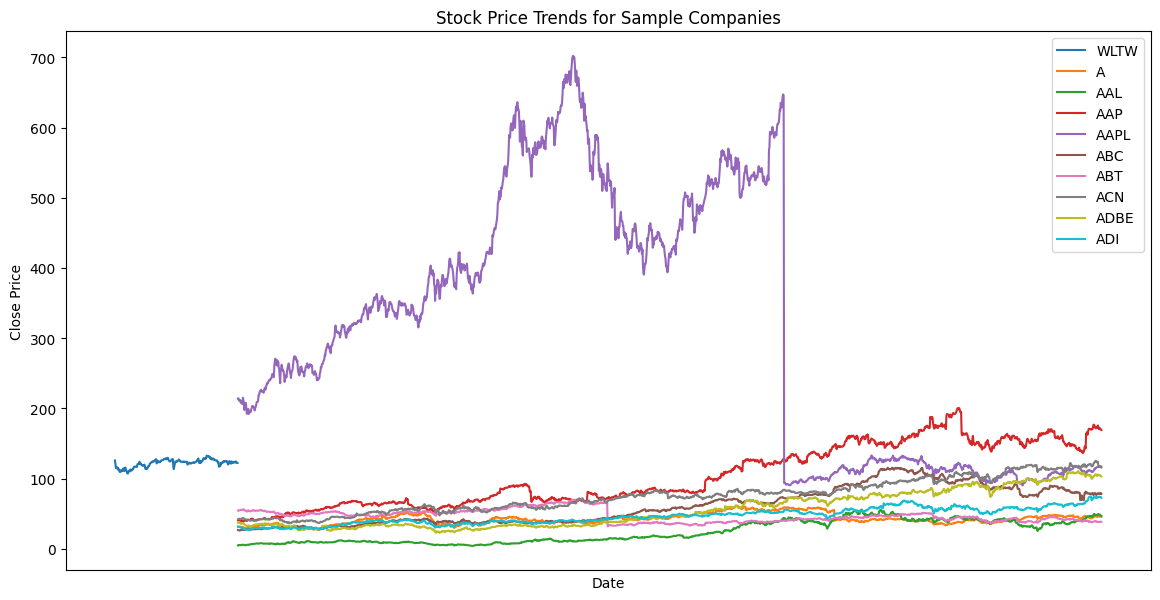

In [25]:

sample_symbols = prices['symbol'].unique()[:10]
sample_prices = prices[prices['symbol'].isin(sample_symbols)]

plt.figure(figsize=(14, 7))
for symbol in sample_symbols:
    plt.plot(sample_prices[sample_prices['symbol'] == symbol]['date'],
             sample_prices[sample_prices['symbol'] == symbol]['close'], label=symbol)
plt.legend()
plt.title('Stock Price Trends for Sample Companies')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks([])
plt.xlabel('Date')
plt.show()


In [26]:
merged_data.columns

Index(['date', 'symbol', 'open', 'close', 'low', 'high', 'volume',
       'open_adjusted', 'close_adjusted', 'low_adjusted', 'high_adjusted',
       'volume_adjusted', 'Unnamed: 0', 'Ticker Symbol', 'Period Ending',
       'Accounts Payable', 'Accounts Receivable', 'Add'l income/expense items',
       'After Tax ROE', 'Capital Expenditures', 'Capital Surplus',
       'Cash Ratio', 'Cash and Cash Equivalents', 'Changes in Inventories',
       'Common Stocks', 'Cost of Revenue', 'Current Ratio',
       'Deferred Asset Charges', 'Deferred Liability Charges', 'Depreciation',
       'Earnings Before Interest and Tax', 'Earnings Before Tax',
       'Effect of Exchange Rate',
       'Equity Earnings/Loss Unconsolidated Subsidiary', 'Fixed Assets',
       'Goodwill', 'Gross Margin', 'Gross Profit', 'Income Tax',
       'Intangible Assets', 'Interest Expense', 'Inventory', 'Investments',
       'Liabilities', 'Long-Term Debt', 'Long-Term Investments',
       'Minority Interest', 'Misc. Stocks',

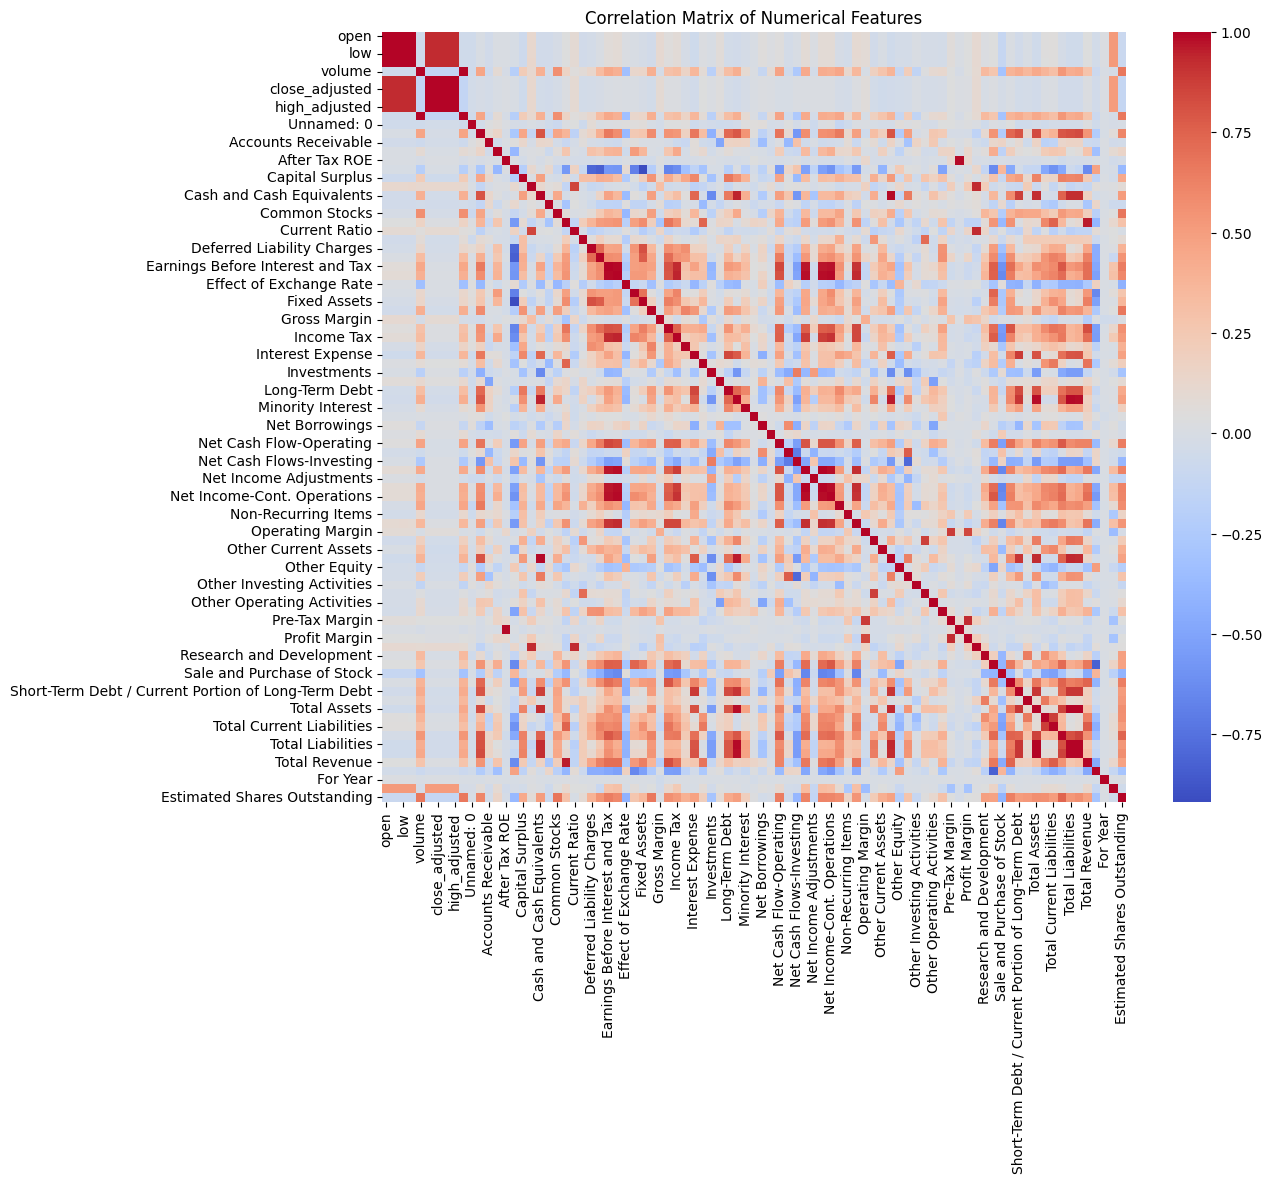

In [27]:
# Assuming 'merged_data' is your DataFrame
# Select only numerical features for correlation analysis
numerical_features = merged_data.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_features.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


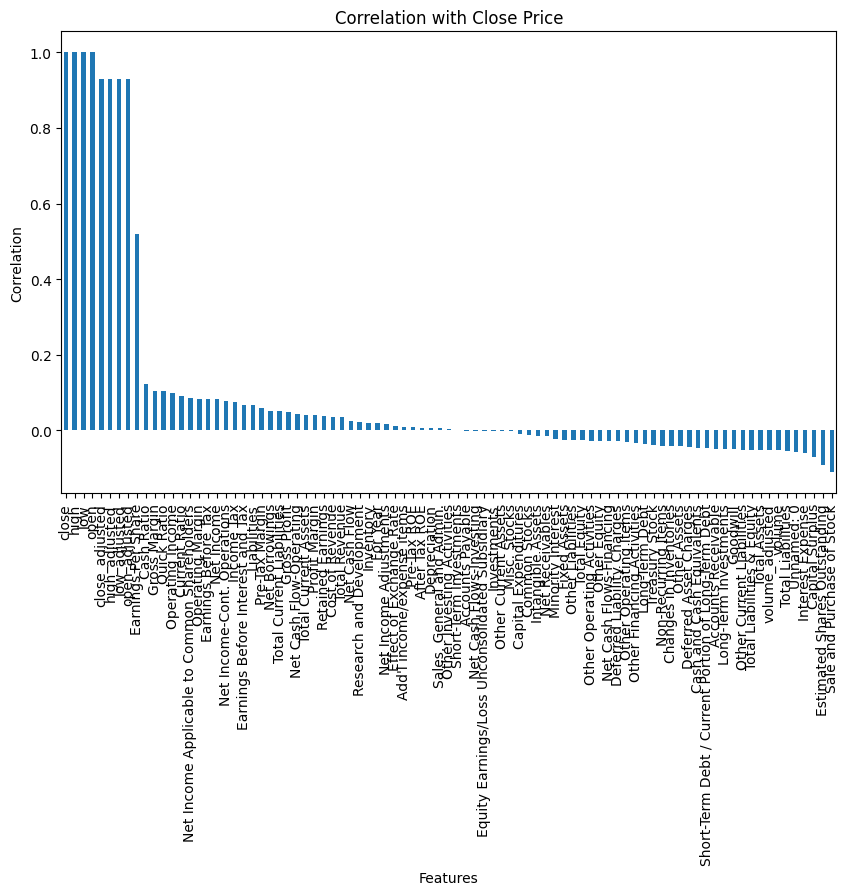

In [28]:
# Assuming 'merged_data' is your DataFrame
# Select only numerical features for correlation analysis
numerical_features = merged_data.select_dtypes(include=np.number)

# Calculate the correlation of other features with the 'close' price
correlation_with_close = numerical_features.corr()['close'].sort_values(ascending=False)

# You can also visualize the correlation with a bar plot
plt.figure(figsize=(10, 6))
correlation_with_close.plot(kind='bar')
plt.title('Correlation with Close Price')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=90)
plt.show()


## Feature Selection

In [29]:
# Filter features with correlation less than 0.6 (positive or negative)
selected_features = correlation_with_close[(correlation_with_close < 0.6) & (correlation_with_close > -0.6)].index.tolist()

# Remove features that have no or very little correlation with 'close' price
selected_features = [feature for feature in selected_features if abs(correlation_with_close[feature]) > 0.1]

print("Selected features:", selected_features)


Selected features: ['Earnings Per Share', 'Cash Ratio', 'Gross Margin', 'Quick Ratio', 'Operating Income', 'Sale and Purchase of Stock']


In [30]:
# Create a new DataFrame 'microsoft' with selected columns for Microsoft data
microsoft = microsoft_data[['date', 'open', 'close', 'volume', 'low', 'high'] + selected_features]


In [31]:
microsoft

,date,open,close,volume,low,high,Earnings Per Share,Cash Ratio,Gross Margin,Quick Ratio,Operating Income,Sale and Purchase of Stock
1042,2010-01-04,30.620001,30.950001,38409100.0,30.590000,31.100000,2.61,206.0,74.0,266.0,2.676400e+10,-4.429000e+09
1043,2010-01-04,30.620001,30.950001,38409100.0,30.590000,31.100000,2.66,188.0,69.0,245.0,2.775900e+10,-6.709000e+09
1044,2010-01-04,30.620001,30.950001,38409100.0,30.590000,31.100000,1.49,194.0,65.0,241.0,1.816100e+10,-1.380900e+10
1045,2010-01-04,30.620001,30.950001,38409100.0,30.590000,31.100000,2.12,191.0,62.0,231.0,2.018200e+10,-1.530100e+10
2706,2010-01-05,30.850000,30.959999,49749600.0,30.639999,31.100000,2.61,206.0,74.0,266.0,2.676400e+10,-4.429000e+09
...,...,...,...,...,...,...,...,...,...,...,...,...
3023475,2016-12-29,62.860001,62.900002,10250600.0,62.730000,63.200001,2.66,188.0,69.0,245.0,2.775900e+10,-6.709000e+09
3025244,2016-12-30,62.959999,62.139999,25579900.0,62.029999,62.990002,2.66,188.0,69.0,245.0,2.775900e+10,-6.709000e+09
3025245,2016-12-30,62.959999,62.139999,25579900.0,62.029999,62.990002,1.49,194.0,65.0,241.0,1.816100e+10,-1.380900e+10
3025243,2016-12-30,62.959999,62.139999,25579900.0,62.029999,62.990002,2.61,206.0,74.0,266.0,2.676400e+10,-4.429000e+09


## Feature Engineering

In [32]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=6bb8e0c971f1d1518cee633f9e2f68989914e7823294cac6970a5727a32c04fe
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [33]:
import ta
from ta.volatility import  BollingerBands
from ta.trend import MACD, ADXIndicator
from ta.momentum import RSIIndicator

In [34]:
# Calculate RSI
microsoft['RSI'] = RSIIndicator(microsoft['close']).rsi()

# Calculate Moving Averages
microsoft['MV20'] = microsoft['close'].rolling(window=20).mean()
microsoft['MV50'] = microsoft['close'].rolling(window=50).mean()
microsoft['MV100'] = microsoft['close'].rolling(window=100).mean()
microsoft['MV200'] = microsoft['close'].rolling(window=200).mean()

<ipython-input-34-4e2ee1c675f9>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  microsoft['RSI'] = RSIIndicator(microsoft['close']).rsi()
<ipython-input-34-4e2ee1c675f9>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  microsoft['MV20'] = microsoft['close'].rolling(window=20).mean()
<ipython-input-34-4e2ee1c675f9>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

In [35]:
# Calculate MACD
macd = MACD(microsoft['close'])
microsoft['MACD'] = macd.macd()
microsoft['MACD_signal'] = macd.macd_signal()
microsoft['MACD_diff'] = macd.macd_diff()

# Calculate ADX
adx = ADXIndicator(microsoft['high'], microsoft['low'], microsoft['close'])
microsoft['ADX'] = adx.adx()
microsoft['ADX_pos'] = adx.adx_pos()
microsoft['ADX_neg'] = adx.adx_neg()


<ipython-input-35-0075a6fc2979>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  microsoft['MACD'] = macd.macd()
<ipython-input-35-0075a6fc2979>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  microsoft['MACD_signal'] = macd.macd_signal()
<ipython-input-35-0075a6fc2979>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [36]:
# Calculate Bollinger Bands
indicator_bb = BollingerBands(close=microsoft["close"], window=20, window_dev=2)
microsoft['bb_bbm'] = indicator_bb.bollinger_mavg()
microsoft['bb_bbh'] = indicator_bb.bollinger_hband()
microsoft['bb_bbl'] = indicator_bb.bollinger_lband()
microsoft['bb_bbw'] = indicator_bb.bollinger_wband()


<ipython-input-36-1061765ed30f>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  microsoft['bb_bbm'] = indicator_bb.bollinger_mavg()
<ipython-input-36-1061765ed30f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  microsoft['bb_bbh'] = indicator_bb.bollinger_hband()
<ipython-input-36-1061765ed30f>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

# Model Training

In [37]:
# Split data into training and testing sets (80:10 ratio)
train_size = int(len(microsoft) * 0.8)
train_df = microsoft[:train_size]
test_df = microsoft[train_size:]

# Target feature is 'close'

print(f"Training data size: {len(train_df)}")
print(f"Testing data size: {len(test_df)}")


Training data size: 5638
Testing data size: 1410


In [38]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

In [39]:
train_df.columns

Index(['date', 'open', 'close', 'volume', 'low', 'high', 'Earnings Per Share',
       'Cash Ratio', 'Gross Margin', 'Quick Ratio', 'Operating Income',
       'Sale and Purchase of Stock', 'RSI', 'MV20', 'MV50', 'MV100', 'MV200',
       'MACD', 'MACD_signal', 'MACD_diff', 'ADX', 'ADX_pos', 'ADX_neg',
       'bb_bbm', 'bb_bbh', 'bb_bbl', 'bb_bbw'],
      dtype='object')

In [40]:
# Remove the specified columns from train_df and test_df
train_df = train_df.drop(['date'], axis=1)
test_df = test_df.drop(['date'], axis=1)


In [41]:
# Prepare data for training
X_train = train_df.drop('close', axis=1)
y_train = train_df['close']

X_test = test_df.drop('close', axis=1)
y_test = test_df['close']


In [42]:
# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2, 0.5],
}

# Create an XGBoost regressor
xgb_model = XGBRegressor()

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2, 0.5],
                         'n_estimators': [100, 200, 300, 500]},
             scoring='neg_mean_squared_error')

In [43]:
# Print the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)




Best parameters: {'learning_rate': 0.2, 'n_estimators': 100}
Best score: -3.879349588572996


In [44]:
# Get the best XGBoost model from the grid search
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_xgb_model.predict(X_test)

In [45]:
# Evaluate the model performance using various metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 42.14207896493684
Root Mean Squared Error (RMSE): 6.491693073839585
Mean Absolute Error (MAE): 5.267778030217164
R-squared (R2): -0.7361268401312007


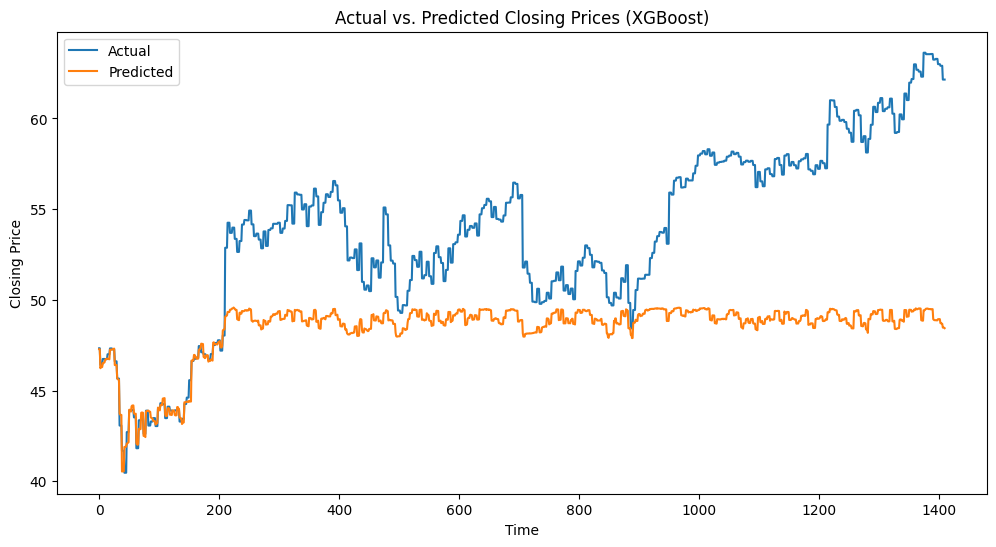

In [46]:
# Visualize the actual vs. predicted closing prices
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.title('Actual vs. Predicted Closing Prices (XGBoost)')
plt.legend()
plt.show()
